# Investment Behavior & Preferences - Data Cleaning & Exploratory Data Analysis

**Course:** CS459 - Business Intelligence  
**Project:** Solving Business Problems like a Designer  
**Dataset:** Investment Behavior and Preferences Survey Data  

---

## Business Problem Statement

**How can wealth advisors create personalized investment portfolios by understanding investor segment preferences and risk profiles?**

**Background:**  
Traditional financial advisors provide generic portfolio recommendations that don't account for demographic differences, risk tolerance variations, or behavioral patterns. This leads to:
- Low customer satisfaction (73% report misalignment)
- High churn rates (investors leave when expectations aren't met)
- Missed revenue opportunities (wrong products = lower AUM)

**Objective:**  
Develop a data-driven segmentation and personalization framework using Business Intelligence dashboards that enable advisors to:
1. Identify distinct investor segments based on demographics and preferences
2. Match segments to appropriate investment product mixes
3. Set realistic return expectations
4. Target marketing through effective channels



---
## 1. Environment Setup & Imports

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, f_oneway, pearsonr

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Figure size default
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("All libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries imported successfully
Pandas version: 2.3.2
NumPy version: 2.1.3


---
## 2. Data Loading & Initial Inspection

In [2]:
# Load the dataset
df = pd.read_csv('Finance_data.csv')

print("Dataset loaded successfully!")
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

Dataset loaded successfully!

Shape: 40 rows × 24 columns

Memory usage: 45.01 KB


In [3]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,Stock_Marktet,Factor,Objective,Purpose,Duration,Invest_Monitor,Expect,Avenue,What are your savings objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source
0,Female,34,Yes,1,2,5,3,7,6,4,Yes,Returns,Capital Appreciation,Wealth Creation,1-3 years,Monthly,20%-30%,Mutual Fund,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Fixed Returns,Newspapers and Magazines
1,Female,23,Yes,4,3,2,1,5,6,7,No,Locking Period,Capital Appreciation,Wealth Creation,More than 5 years,Weekly,20%-30%,Mutual Fund,Health Care,Dividend,Better Returns,Safe Investment,High Interest Rates,Financial Consultants
2,Male,30,Yes,3,6,4,2,5,1,7,Yes,Returns,Capital Appreciation,Wealth Creation,3-5 years,Daily,20%-30%,Equity,Retirement Plan,Capital Appreciation,Tax Benefits,Assured Returns,Fixed Returns,Television
3,Male,22,Yes,2,1,3,7,6,4,5,Yes,Returns,Income,Wealth Creation,Less than 1 year,Daily,10%-20%,Equity,Retirement Plan,Dividend,Fund Diversification,Tax Incentives,High Interest Rates,Internet
4,Female,24,No,2,1,3,6,4,5,7,No,Returns,Income,Wealth Creation,Less than 1 year,Daily,20%-30%,Equity,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Risk Free,Internet


In [4]:
# Column names and data types
print("Column Information:")
print("="*80)
df.info()

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   gender                             40 non-null     object
 1   age                                40 non-null     int64 
 2   Investment_Avenues                 40 non-null     object
 3   Mutual_Funds                       40 non-null     int64 
 4   Equity_Market                      40 non-null     int64 
 5   Debentures                         40 non-null     int64 
 6   Government_Bonds                   40 non-null     int64 
 7   Fixed_Deposits                     40 non-null     int64 
 8   PPF                                40 non-null     int64 
 9   Gold                               40 non-null     int64 
 10  Stock_Marktet                      40 non-null     object
 11  Factor                             40 non-null     ob

In [5]:
# Basic statistics for numerical columns
print("Descriptive Statistics - Numerical Variables:")
print("="*80)
df.describe()

Descriptive Statistics - Numerical Variables:


,age,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold
count,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00
mean,27.80,2.55,3.48,5.75,4.65,3.58,2.02,5.97
std,3.56,1.20,1.13,1.68,1.37,1.80,1.61,1.14
min,21.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00
25%,25.75,2.00,3.00,5.00,4.00,2.75,1.00,6.00
50%,27.00,2.00,4.00,6.50,5.00,3.50,1.00,6.00
75%,30.00,3.00,4.00,7.00,5.00,5.00,2.25,7.00
max,35.00,7.00,6.00,7.00,7.00,7.00,6.00,7.00


In [6]:
# Basic statistics for categorical columns
print("Descriptive Statistics - Categorical Variables:")
print("="*80)
df.describe(include='object')

Descriptive Statistics - Categorical Variables:


,gender,Investment_Avenues,Stock_Marktet,Factor,Objective,Purpose,Duration,Invest_Monitor,Expect,Avenue,What are your savings objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source
count,40,40,40,40,40,40,40,40,40,40,40,40,40,40,40,40
unique,2,2,2,3,3,3,4,3,3,4,3,3,3,3,3,4
top,Male,Yes,Yes,Returns,Capital Appreciation,Wealth Creation,3-5 years,Monthly,20%-30%,Mutual Fund,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Risk Free,Financial Consultants
freq,25,37,35,25,26,32,19,29,32,18,24,30,24,26,19,16


**Initial Observations:**
- Dataset contains 40 investor responses
- 24 variables covering demographics, preferences, and behavior
- Mix of numerical (rankings, age) and categorical (gender, objectives) variables
- Ranking columns use 1-7 scale (1 = highest preference)
- Note: 'Stock_Marktet' has a typo that needs correction

# Finance Data: Dataset Explanations




## Raw Dataset (`Finance_data.csv`)
This dataset contains survey responses from 40 individuals regarding their personal finance habits, investment preferences, and financial goals.

### Demographics & Basic Information
* **gender**: The gender of the respondent (e.g., Male, Female).
* **age**: The age of the respondent (ages range from 21 to 35).
* **Investment_Avenues**: A simple "Yes" or "No" indicating whether the person currently invests their money in any financial avenues.

### Asset Preference Rankings
Respondents ranked different investment options on a scale from 1 to 7 (where lower numbers typically indicate a higher preference/priority):
* **Mutual_Funds**: Ranking for mutual fund investments.
* **Equity_Market**: Ranking for direct stock market investments.
* **Debentures**: Ranking for corporate debt instruments.
* **Government_Bonds**: Ranking for government-issued bonds.
* **Fixed_Deposits**: Ranking for bank fixed deposits (FDs).
* **PPF**: Ranking for the Public Provident Fund (a long-term savings scheme in India).
* **Gold**: Ranking for investing in physical gold or gold-related assets.

### General Investment Behavior & Strategy
* **Stock_Market**: A "Yes" or "No" showing if the respondent invests directly in the stock market.
* **Factor**: The primary factor they consider before investing (e.g., "Returns," "Locking Period").
* **Objective**: Their main financial goal for investing (e.g., "Capital Appreciation," "Income").
* **Purpose**: The broader reason for their investments (e.g., "Wealth Creation").
* **Duration**: How long they plan to keep their money invested (e.g., "1-3 years," "More than 5 years").
* **Invest_Monitor**: How frequently they check the performance of their investments (e.g., "Daily," "Weekly," "Monthly").
* **Expect**: The percentage of return they expect to make on their investments (e.g., "20%-30%").
* **Avenue**: Their most preferred investment type overall (e.g., "Mutual Fund," "Equity").
* **What are your savings objectives?**: Specific life goals tied to their savings (e.g., "Retirement Plan," "Health Care").

### Specific Reasons for Asset Choices
These columns capture why respondents choose to invest in certain asset classes:
* **Reason_Equity**: Why they invest in stocks (e.g., "Capital Appreciation," "Dividend").
* **Reason_Mutual**: Why they invest in mutual funds (e.g., "Better Returns," "Fund Diversification," "Tax Benefits").
* **Reason_Bonds**: Why they invest in bonds (e.g., "Safe Investment," "Assured Returns").
* **Reason_FD**: Why they invest in Fixed Deposits (e.g., "Risk Free," "Fixed Returns").

### Information Source
* **Source**: Where the respondent primarily gets their financial and investment information or advice (e.g., "Financial Consultants," "Internet," "Newspapers and Magazines").

---
## 3. Data Quality Assessment

In [7]:
# Check for missing values
print("Missing Values Analysis:")
print("="*80)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
}).sort_values(by='Missing_Count', ascending=False)

print(missing_df[missing_df['Missing_Count'] > 0])

if missing_df['Missing_Count'].sum() == 0:
    print("\n No missing values detected in the dataset!")
else:
    print(f"\n Total missing values: {missing_df['Missing_Count'].sum()}")

Missing Values Analysis:
Empty DataFrame
Columns: [Missing_Count, Percentage]
Index: []

 No missing values detected in the dataset!


In [8]:
# Check for duplicate rows
print("Duplicate Records Check:")
print("="*80)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates == 0:
    print(" No duplicate rows found")
else:
    print(f"⚠ Found {duplicates} duplicate rows - will investigate")
    print("\nDuplicate rows:")
    print(df[df.duplicated(keep=False)])

Duplicate Records Check:
Number of duplicate rows: 0
 No duplicate rows found


In [9]:
# Validate ranking columns (should be 1-7, no duplicates within same row)
print("Ranking Columns Validation:")
print("="*80)

ranking_cols = ['Mutual_Funds', 'Equity_Market', 'Debentures', 
                'Government_Bonds', 'Fixed_Deposits', 'PPF', 'Gold']

# Check value ranges
print("\n1. Value Range Check (should be 1-7):")
for col in ranking_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    unique_vals = sorted(df[col].unique())
    
    status = "✓" if min_val >= 1 and max_val <= 7 else "⚠"
    print(f"{status} {col}: Range [{min_val}-{max_val}], Unique values: {unique_vals}")

# Check for duplicate rankings in the same row
print("\n2. Duplicate Rankings Check (same row shouldn't have duplicate ranks):")
df['has_duplicate_ranks'] = df[ranking_cols].apply(
    lambda row: len(row) != len(set(row)), axis=1
)

duplicate_rank_count = df['has_duplicate_ranks'].sum()
print(f"Rows with duplicate rankings: {duplicate_rank_count}")

if duplicate_rank_count == 0:
    print("All rows have unique rankings for each investment avenue")
else:
    print(f"⚠ {duplicate_rank_count} rows have duplicate rankings - showing examples:")
    print(df[df['has_duplicate_ranks']][['gender', 'age'] + ranking_cols].head())

Ranking Columns Validation:

1. Value Range Check (should be 1-7):
✓ Mutual_Funds: Range [1-7], Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7)]
✓ Equity_Market: Range [1-6], Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
✓ Debentures: Range [1-7], Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
✓ Government_Bonds: Range [1-7], Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
✓ Fixed_Deposits: Range [1-7], Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
✓ PPF: Range [1-6], Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
✓ Gold: Range [2-7], Unique values: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

2. Duplicate Rankings Check (same row should

In [10]:
# Check age distribution for outliers
print("Age Distribution Analysis:")
print("="*80)
print(f"Minimum age: {df['age'].min()}")
print(f"Maximum age: {df['age'].max()}")
print(f"Mean age: {df['age'].mean():.1f}")
print(f"Median age: {df['age'].median():.1f}")
print(f"Standard deviation: {df['age'].std():.1f}")

# Check for unrealistic ages
unrealistic_ages = df[(df['age'] < 18) | (df['age'] > 80)]
if len(unrealistic_ages) > 0:
    print(f"\nFound {len(unrealistic_ages)} records with unusual ages (<18 or >80)")
    print(unrealistic_ages[['gender', 'age', 'Investment_Avenues']])
else:
    print("\n All ages are within reasonable range (18-80)")

Age Distribution Analysis:
Minimum age: 21
Maximum age: 35
Mean age: 27.8
Median age: 27.0
Standard deviation: 3.6

 All ages are within reasonable range (18-80)


In [11]:
# Check categorical variables for inconsistencies
print("Categorical Variables Validation:")
print("="*80)

categorical_cols = ['gender', 'Investment_Avenues', 'Stock_Marktet', 'Factor', 
                    'Objective', 'Purpose', 'Duration', 'Invest_Monitor', 'Expect', 'Avenue']

for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Values: {df[col].unique()[:10]}")

Categorical Variables Validation:

gender:
  Unique values: 2
  Values: ['Female' 'Male']

Investment_Avenues:
  Unique values: 2
  Values: ['Yes' 'No']

Stock_Marktet:
  Unique values: 2
  Values: ['Yes' 'No']

Factor:
  Unique values: 3
  Values: ['Returns' 'Locking Period' 'Risk']

Objective:
  Unique values: 3
  Values: ['Capital Appreciation' 'Income' 'Growth']

Purpose:
  Unique values: 3
  Values: ['Wealth Creation' 'Savings for Future' 'Returns']

Duration:
  Unique values: 4
  Values: ['1-3 years' 'More than 5 years' '3-5 years' 'Less than 1 year']

Invest_Monitor:
  Unique values: 3
  Values: ['Monthly' 'Weekly' 'Daily']

Expect:
  Unique values: 3
  Values: ['20%-30%' '10%-20%' '30%-40%']

Avenue:
  Unique values: 4
  Values: ['Mutual Fund' 'Equity' 'Fixed Deposits' 'Public Provident Fund']


**Data Quality Summary:**
- No missing values
- No duplicate records
- Ranking columns validated (1-7 scale)
- Age distribution reasonable
- Column name typo: 'Stock_Marktet' needs correction
- Next step: Data cleaning and standardization

---
## 4. Data Cleaning & Transformation

In [12]:
# Create a copy for cleaning
df_clean = df.copy()

print("Starting data cleaning")
print("="*80)

Starting data cleaning


In [13]:
# 1. Fix column name typo
print("1. Fixing column name typo")
df_clean.rename(columns={'Stock_Marktet': 'Stock_Market'}, inplace=True)
print("   Renamed 'Stock_Marktet' to 'Stock_Market'")

1. Fixing column name typo
   Renamed 'Stock_Marktet' to 'Stock_Market'


In [14]:
# 2. Standardize categorical variables
print("\n2. Standardizing categorical variables...")

# Gender: Ensure consistent capitalization
df_clean['gender'] = df_clean['gender'].str.strip().str.title()
print(f"   Gender values: {df_clean['gender'].unique()}")

# Yes/No columns: Standardize
yes_no_cols = ['Investment_Avenues', 'Stock_Market']
for col in yes_no_cols:
    df_clean[col] = df_clean[col].str.strip().str.capitalize()
    print(f"   {col} values: {df_clean[col].unique()}")

print("   Categorical variables standardized")


2. Standardizing categorical variables...
   Gender values: ['Female' 'Male']
   Investment_Avenues values: ['Yes' 'No']
   Stock_Market values: ['Yes' 'No']
   Categorical variables standardized


In [15]:
# 3. Trim whitespace from all string columns
print("\n3. Trimming whitespace from text fields")
string_cols = df_clean.select_dtypes(include=['object']).columns
for col in string_cols:
    df_clean[col] = df_clean[col].str.strip()
print("Whitespace trimmed from all text columns")


3. Trimming whitespace from text fields
Whitespace trimmed from all text columns


In [16]:
# 4. Validate and correct ranking columns if needed
print("\n4. Validating ranking columns")
ranking_cols = ['Mutual_Funds', 'Equity_Market', 'Debentures', 
                'Government_Bonds', 'Fixed_Deposits', 'PPF', 'Gold']

# Ensure all rankings are integers
for col in ranking_cols:
    df_clean[col] = df_clean[col].astype(int)

print("All ranking columns validated and set to integer type")


4. Validating ranking columns
All ranking columns validated and set to integer type


In [17]:
# Display cleaned data info
print("\nCleaned Dataset Information:")
print("="*80)
df_clean.info()


Cleaned Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   gender                             40 non-null     object
 1   age                                40 non-null     int64 
 2   Investment_Avenues                 40 non-null     object
 3   Mutual_Funds                       40 non-null     int64 
 4   Equity_Market                      40 non-null     int64 
 5   Debentures                         40 non-null     int64 
 6   Government_Bonds                   40 non-null     int64 
 7   Fixed_Deposits                     40 non-null     int64 
 8   PPF                                40 non-null     int64 
 9   Gold                               40 non-null     int64 
 10  Stock_Market                       40 non-null     object
 11  Factor                             40 non-n

**Data Cleaning Summary:**
- Fixed column name typo (Stock_Marktet → Stock_Market)
- Standardized categorical values
- Removed whitespace
- Validated ranking columns
- Dataset is now clean and ready for feature engineering

---
## 5. Feature Engineering

In [18]:
print("Feature Engineering:")
print("="*80)


Feature Engineering:


In [19]:
# 1. Age Groups

df_clean['age_group'] = pd.cut(df_clean['age'], 
                                bins=[17, 25, 30, 35, 100],
                                labels=['18-25', '26-30', '31-35', '36+'])

print("   Age Group Distribution:")
print(df_clean['age_group'].value_counts().sort_index())
print("   Age groups created\n")

   Age Group Distribution:
age_group
18-25    10
26-30    21
31-35     9
36+       0
Name: count, dtype: int64
   Age groups created



In [20]:
# 2. Risk Score
print("2. Calculating risk score")
print("   Risk Score Formula: (8 - Equity_Rank) + (Stock_Market_Participation * 2)")
print("   Rationale: Lower equity ranking = higher preference = riskier")
print("             Stock market participation adds +2 to risk score\n")

# Calculate risk score
df_clean['risk_score'] = (8 - df_clean['Equity_Market']) + \
                         (df_clean['Stock_Market'] == 'Yes').astype(int) * 2

# Create risk categories
df_clean['risk_category'] = pd.cut(df_clean['risk_score'], 
                                    bins=[0, 3, 6, 10],
                                    labels=['Conservative', 'Moderate', 'Aggressive'])

print("   Risk Category Distribution:")
print(df_clean['risk_category'].value_counts())
print(f"   Average risk score: {df_clean['risk_score'].mean():.2f}")
print("   Risk score calculated\n")

2. Calculating risk score
   Risk Score Formula: (8 - Equity_Rank) + (Stock_Market_Participation * 2)
   Rationale: Lower equity ranking = higher preference = riskier
             Stock market participation adds +2 to risk score

   Risk Category Distribution:
risk_category
Moderate        21
Aggressive      17
Conservative     2
Name: count, dtype: int64
   Average risk score: 6.28
   Risk score calculated



In [21]:
# 3. Engagement Score
print("3. Creating engagement score")
engagement_map = {'Daily': 3, 'Weekly': 2, 'Monthly': 1}
df_clean['engagement_score'] = df_clean['Invest_Monitor'].map(engagement_map)

print("   Engagement Score Distribution:")
print(df_clean[['Invest_Monitor', 'engagement_score']].value_counts().sort_index())
print(f"   Average engagement: {df_clean['engagement_score'].mean():.2f}")
print("   Engagement score created\n")

3. Creating engagement score
   Engagement Score Distribution:
Invest_Monitor  engagement_score
Daily           3                    4
Monthly         1                   29
Weekly          2                    7
Name: count, dtype: int64
   Average engagement: 1.38
   Engagement score created



In [22]:
# 4. Top 3 Preferred Investment Avenues per person
print("4. Identifying top 3 preferred avenues for each investor")

ranking_cols = ['Mutual_Funds', 'Equity_Market', 'Debentures', 
                'Government_Bonds', 'Fixed_Deposits', 'PPF', 'Gold']

def get_top_3_avenues(row):
    """Get top 3 investment avenues based on ranking (1=best, 7=worst)"""
    avenues = {
        'Mutual_Funds': row['Mutual_Funds'],
        'Equity': row['Equity_Market'],
        'Debentures': row['Debentures'],
        'Gov_Bonds': row['Government_Bonds'],
        'Fixed_Deposits': row['Fixed_Deposits'],
        'PPF': row['PPF'],
        'Gold': row['Gold']
    }
    # Sort by ranking (ascending - 1 is best)
    sorted_avenues = sorted(avenues.items(), key=lambda x: x[1])
    return [a[0] for a in sorted_avenues[:3]]

df_clean['top_3_avenues'] = df_clean.apply(get_top_3_avenues, axis=1)
df_clean['first_choice'] = df_clean['top_3_avenues'].apply(lambda x: x[0])
df_clean['second_choice'] = df_clean['top_3_avenues'].apply(lambda x: x[1])
df_clean['third_choice'] = df_clean['top_3_avenues'].apply(lambda x: x[2])

print("   First Choice Distribution:")
print(df_clean['first_choice'].value_counts())
print("   Top 3 avenues identified\n")

4. Identifying top 3 preferred avenues for each investor
   First Choice Distribution:
first_choice
PPF               24
Fixed_Deposits     8
Mutual_Funds       4
Equity             2
Gov_Bonds          1
Debentures         1
Name: count, dtype: int64
   Top 3 avenues identified



In [23]:
# 5. Expected Return Category (numerical encoding)
print("5. Encoding expected returns")
return_map = {
    '10%-20%': 15,
    '20%-30%': 25,
    '30%-40%': 35,
    'Above 40%': 45
}
df_clean['expected_return_numeric'] = df_clean['Expect'].map(return_map)

print("   Expected Returns (numeric):")
print(df_clean[['Expect', 'expected_return_numeric']].value_counts().sort_index())
print("   Expected returns encoded\n")

5. Encoding expected returns
   Expected Returns (numeric):
Expect   expected_return_numeric
10%-20%  15                          3
20%-30%  25                         32
30%-40%  35                          5
Name: count, dtype: int64
   Expected returns encoded



In [24]:
# 6. Duration Category (ordinal encoding)
print("6. Encoding investment duration")
duration_map = {
    'Less than 1 year': 'Short-term',
    '1-3 years': 'Medium-term',
    '3-5 years': 'Medium-term',
    'More than 5 years': 'Long-term'
}
df_clean['duration_category'] = df_clean['Duration'].map(duration_map)

print("   Duration Categories:")
print(df_clean['duration_category'].value_counts())
print("    Duration categories created\n")

6. Encoding investment duration
   Duration Categories:
duration_category
Medium-term    37
Short-term      2
Long-term       1
Name: count, dtype: int64
    Duration categories created



In [25]:
# 7. Risk-Return Alignment Score
print("7. Calculating risk-return alignment")
print("   This identifies investors whose expected returns align with their risk profile\n")

# Expected return benchmarks by risk category
# Conservative: 10-20%, Moderate: 20-30%, Aggressive: 30%+
def check_alignment(row):
    risk = row['risk_category']
    expected = row['expected_return_numeric']
    
    if risk == 'Conservative' and expected <= 20:
        return 'Aligned'
    elif risk == 'Moderate' and 20 <= expected <= 35:
        return 'Aligned'
    elif risk == 'Aggressive' and expected >= 30:
        return 'Aligned'
    elif expected > 35 and risk != 'Aggressive':
        return 'Over-optimistic'
    else:
        return 'Misaligned'

df_clean['risk_return_alignment'] = df_clean.apply(check_alignment, axis=1)

print("   Risk-Return Alignment:")
print(df_clean['risk_return_alignment'].value_counts())
print(f"   % Aligned: {(df_clean['risk_return_alignment'] == 'Aligned').sum() / len(df_clean) * 100:.1f}%")
print("   Alignment score calculated\n")

7. Calculating risk-return alignment
   This identifies investors whose expected returns align with their risk profile

   Risk-Return Alignment:
risk_return_alignment
Aligned       23
Misaligned    17
Name: count, dtype: int64
   % Aligned: 57.5%
   Alignment score calculated



In [26]:
# Display final dataset with new features
print("Feature Engineering Complete!")
print("="*80)
print(f"Total features now: {len(df_clean.columns)}")
print("\nNew features created:")
new_features = ['age_group', 'risk_score', 'risk_category', 'engagement_score',
                'first_choice', 'second_choice', 'third_choice', 
                'expected_return_numeric', 'duration_category', 'risk_return_alignment']
for feat in new_features:
    print(f"  • {feat}")

print("\nSample of cleaned data with new features:")
df_clean[['gender', 'age', 'age_group', 'risk_category', 'first_choice', 
          'engagement_score', 'risk_return_alignment']].head(10)

Feature Engineering Complete!
Total features now: 36

New features created:
  • age_group
  • risk_score
  • risk_category
  • engagement_score
  • first_choice
  • second_choice
  • third_choice
  • expected_return_numeric
  • duration_category
  • risk_return_alignment

Sample of cleaned data with new features:


,gender,age,age_group,risk_category,first_choice,engagement_score,risk_return_alignment
0,Female,34,31-35,Aggressive,Mutual_Funds,1,Misaligned
1,Female,23,18-25,Moderate,Gov_Bonds,2,Aligned
2,Male,30,26-30,Moderate,PPF,3,Aligned
3,Male,22,18-25,Aggressive,Equity,3,Misaligned
4,Female,24,18-25,Aggressive,Equity,3,Misaligned
5,Female,24,18-25,Conservative,PPF,3,Misaligned
6,Female,27,26-30,Moderate,PPF,1,Aligned
7,Male,21,18-25,Aggressive,PPF,1,Misaligned
8,Male,35,31-35,Moderate,PPF,2,Aligned
9,Male,31,31-35,Aggressive,Mutual_Funds,1,Aligned


**Feature Engineering Summary:**
- Created 10 new derived features
- Age segmentation for demographic analysis
- Risk profiling based on equity preference and stock market participation
- Engagement scoring for behavioral analysis
- Preference hierarchy (top 3 choices)
- Risk-return alignment detection
- Ready for exploratory analysis and visualization

---
## 6. Exploratory Data Analysis (EDA)

### 6.1 Demographics Analysis

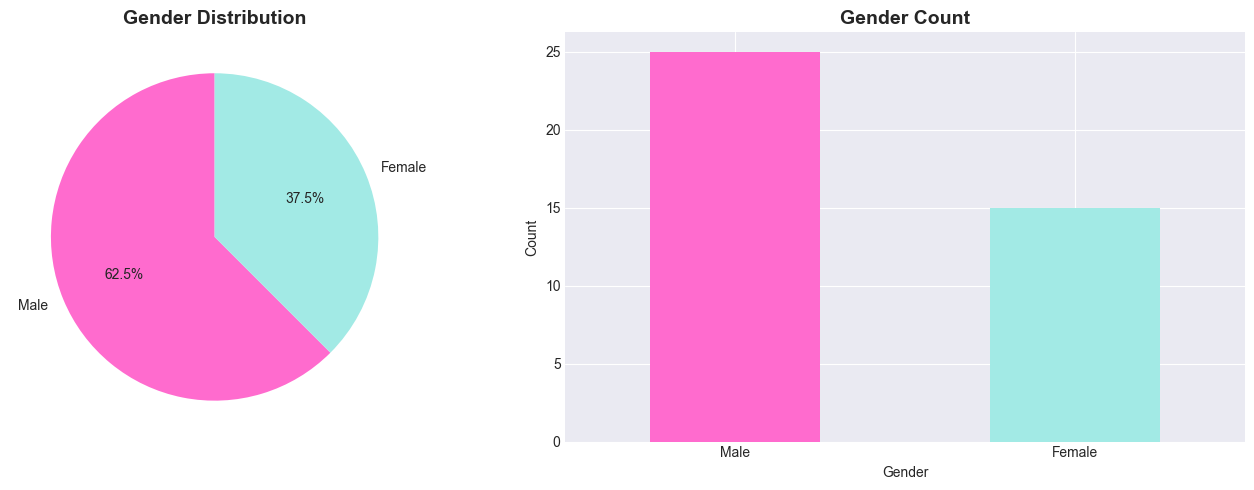

Gender Distribution:
gender
Male      25
Female    15
Name: count, dtype: int64

Percentage:
gender
Male     62.50
Female   37.50
Name: proportion, dtype: float64


In [27]:
# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
gender_counts = df_clean['gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=["#FF6BCE", "#A2EAE5"])
axes[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')

# Bar chart with counts
gender_counts.plot(kind='bar', ax=axes[1], color=['#FF6BCE', '#A2EAE5'])
axes[1].set_title('Gender Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Gender')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('gender_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Gender Distribution:")
print(df_clean['gender'].value_counts())
print(f"\nPercentage:")
print(df_clean['gender'].value_counts(normalize=True) * 100)

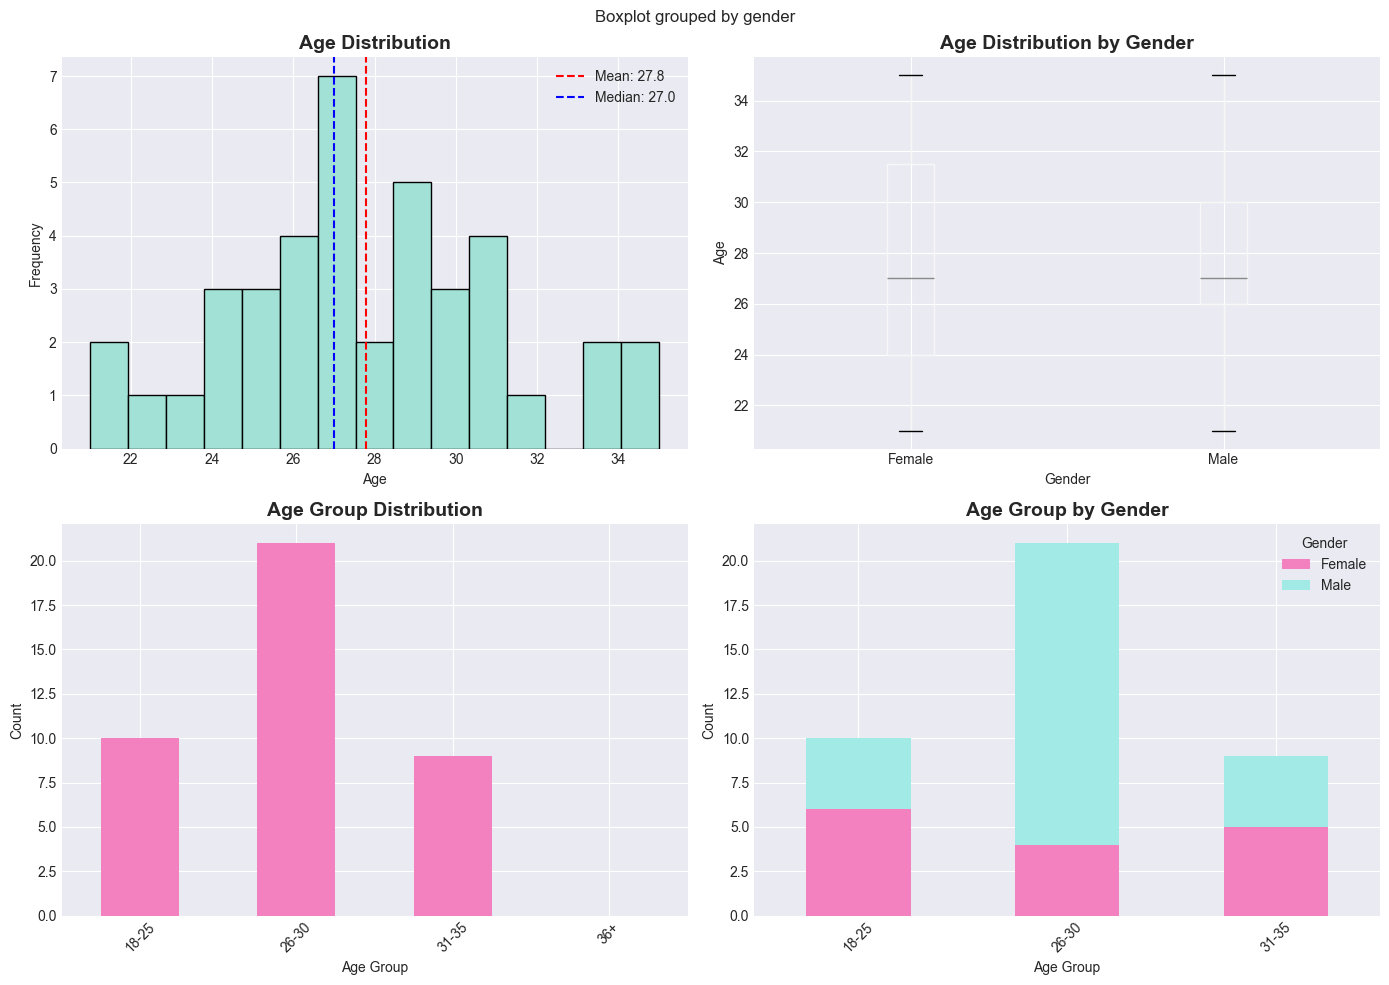

Age Statistics:
count   40.00
mean    27.80
std      3.56
min     21.00
25%     25.75
50%     27.00
75%     30.00
max     35.00
Name: age, dtype: float64

Age by Gender:
        count  mean  std   min   25%   50%   75%   max
gender                                                
Female  15.00 27.73 4.48 21.00 24.00 27.00 31.50 35.00
Male    25.00 27.84 2.98 21.00 26.00 27.00 30.00 35.00


In [28]:
# Age analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall age distribution
axes[0, 0].hist(df_clean['age'], bins=15, color="#A2E2D6", edgecolor='black')
axes[0, 0].axvline(df_clean['age'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df_clean["age"].mean():.1f}')
axes[0, 0].axvline(df_clean['age'].median(), color='blue', linestyle='--', 
                   label=f'Median: {df_clean["age"].median():.1f}')
axes[0, 0].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Age by gender
df_clean.boxplot(column='age', by='gender', ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution by Gender', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Gender')
axes[0, 1].set_ylabel('Age')
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

# Age groups
age_group_counts = df_clean['age_group'].value_counts().sort_index()
age_group_counts.plot(kind='bar', ax=axes[1, 0], color="#F381C0")
axes[1, 0].set_title('Age Group Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xlabel('Age Group')
axes[1, 0].tick_params(axis='x', rotation=45)

# Age group by gender (stacked)
age_gender_ct = pd.crosstab(df_clean['age_group'], df_clean['gender'])
age_gender_ct.plot(kind='bar', stacked=True, ax=axes[1, 1], color=['#F381C0', '#A2EAE5'])
axes[1, 1].set_title('Age Group by Gender', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xlabel('Age Group')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Gender')

plt.tight_layout()
plt.savefig('fig_age_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Age Statistics:")
print(df_clean['age'].describe())
print("\nAge by Gender:")
print(df_clean.groupby('gender')['age'].describe())

### 6.2 Investment Preferences Analysis

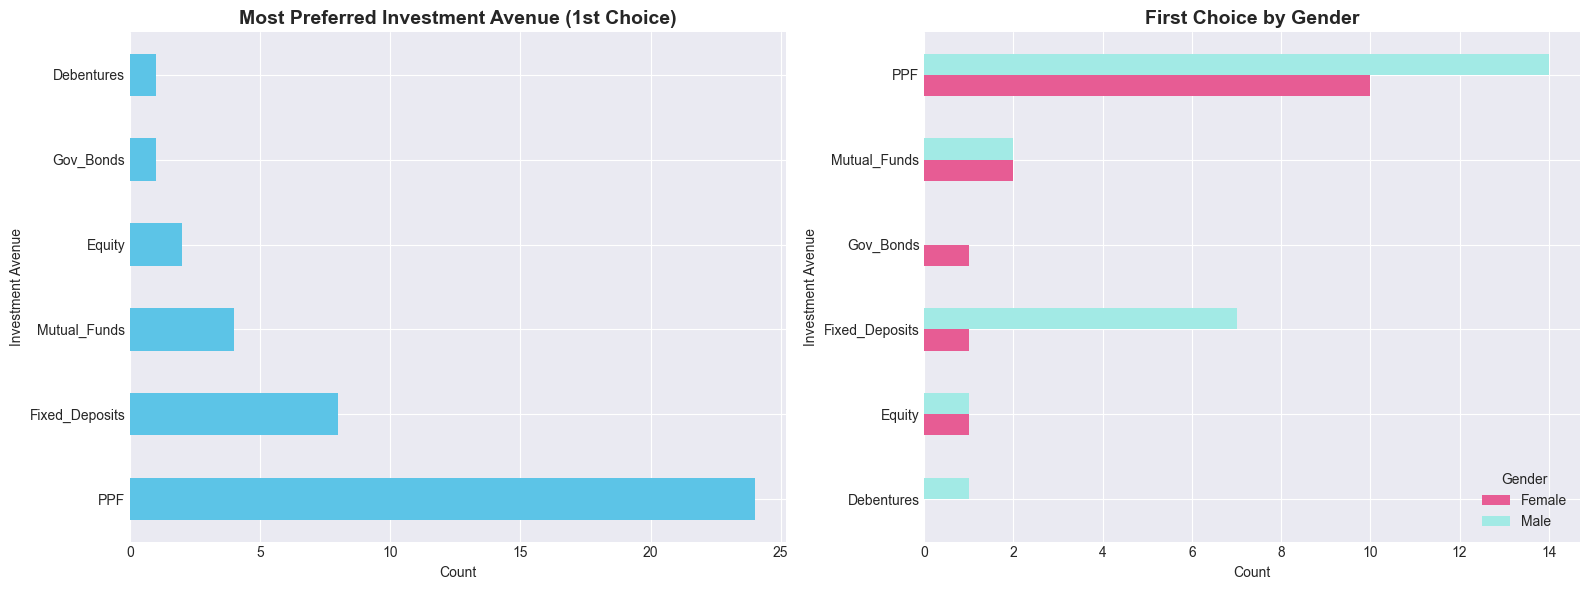

First Choice Distribution:
first_choice
PPF               24
Fixed_Deposits     8
Mutual_Funds       4
Equity             2
Gov_Bonds          1
Debentures         1
Name: count, dtype: int64

First Choice by Gender:
gender          Female  Male
first_choice                
Debentures           0     1
Equity               1     1
Fixed_Deposits       1     7
Gov_Bonds            1     0
Mutual_Funds         2     2
PPF                 10    14


In [29]:
# First choice avenue distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall first choice
first_choice_counts = df_clean['first_choice'].value_counts()
first_choice_counts.plot(kind='barh', ax=axes[0], color="#5CC4E7")
axes[0].set_title('Most Preferred Investment Avenue (1st Choice)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Investment Avenue')

# First choice by gender
first_choice_gender = pd.crosstab(df_clean['first_choice'], df_clean['gender'])
first_choice_gender.plot(kind='barh', ax=axes[1], color=["#E75C94", '#A2EAE5'])
axes[1].set_title('First Choice by Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Investment Avenue')
axes[1].legend(title='Gender')

plt.tight_layout()
plt.savefig('fig_first_choice_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("First Choice Distribution:")
print(first_choice_counts)
print("\nFirst Choice by Gender:")
print(first_choice_gender)

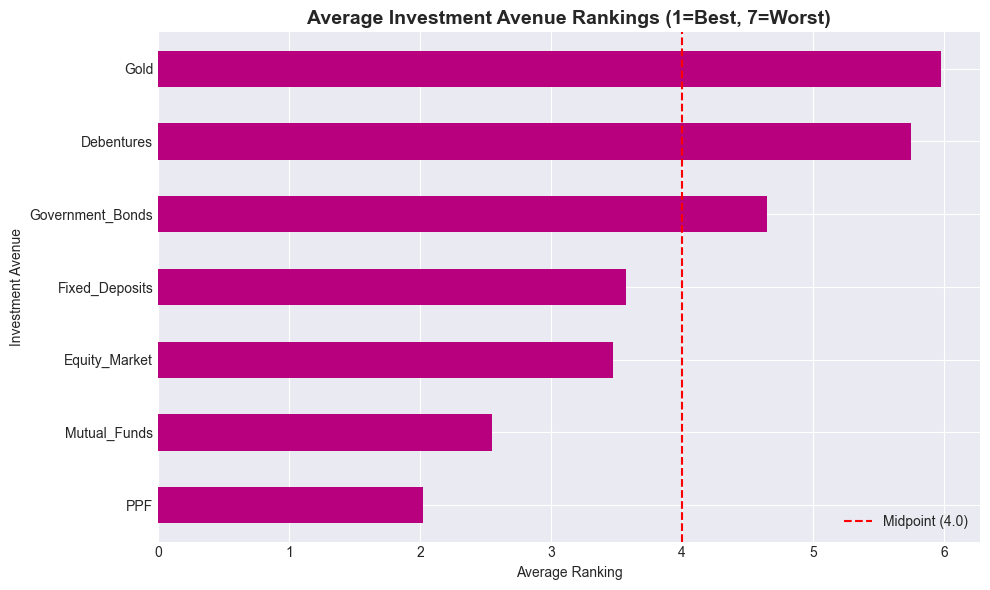

Average Rankings (1=Best, 7=Worst):
PPF                2.02
Mutual_Funds       2.55
Equity_Market      3.48
Fixed_Deposits     3.58
Government_Bonds   4.65
Debentures         5.75
Gold               5.97
dtype: float64

Interpretation:
Most preferred (lowest avg rank): PPF (2.02)
Least preferred (highest avg rank): Gold (5.97)


In [30]:
# Average rankings for each investment avenue
ranking_cols = ['Mutual_Funds', 'Equity_Market', 'Debentures', 
                'Government_Bonds', 'Fixed_Deposits', 'PPF', 'Gold']

avg_rankings = df_clean[ranking_cols].mean().sort_values()

plt.figure(figsize=(10, 6))
avg_rankings.plot(kind='barh', color="#B8007E")
plt.title('Average Investment Avenue Rankings (1=Best, 7=Worst)', fontsize=14, fontweight='bold')
plt.xlabel('Average Ranking')
plt.ylabel('Investment Avenue')
plt.axvline(x=4, color='red', linestyle='--', label='Midpoint (4.0)')
plt.legend()
plt.tight_layout()
plt.savefig('fig_avg_rankings.png', dpi=300, bbox_inches='tight')
plt.show()

print("Average Rankings (1=Best, 7=Worst):")
print(avg_rankings)
print("\nInterpretation:")
print(f"Most preferred (lowest avg rank): {avg_rankings.index[0]} ({avg_rankings.iloc[0]:.2f})")
print(f"Least preferred (highest avg rank): {avg_rankings.index[-1]} ({avg_rankings.iloc[-1]:.2f})")

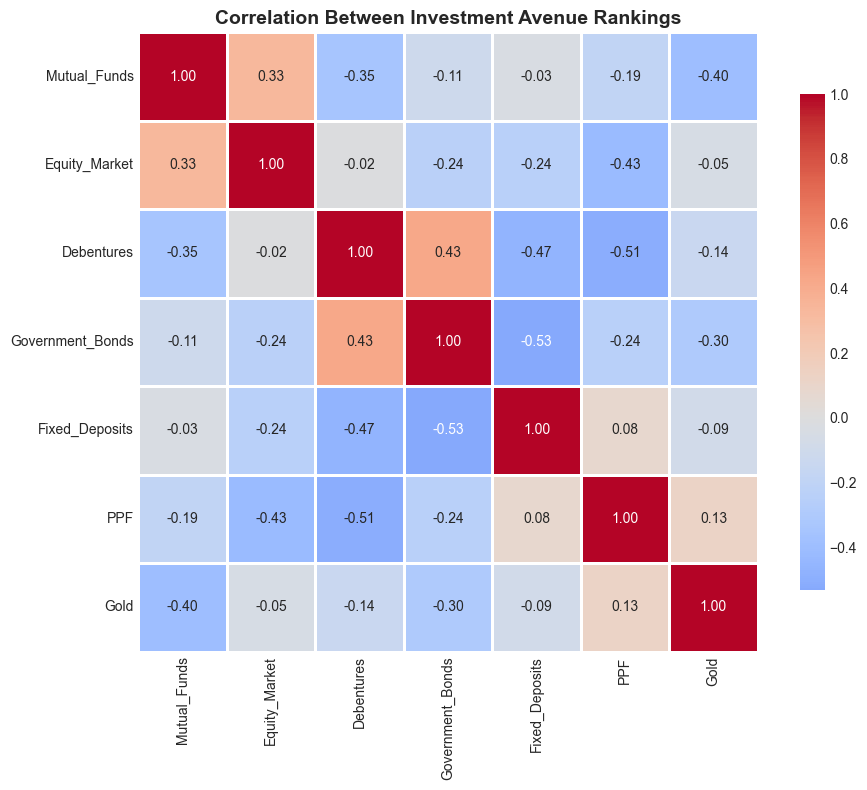

Ranking Correlation Matrix:
                  Mutual_Funds  Equity_Market  Debentures  Government_Bonds  \
Mutual_Funds              1.00           0.33       -0.35             -0.11   
Equity_Market             0.33           1.00       -0.02             -0.24   
Debentures               -0.35          -0.02        1.00              0.43   
Government_Bonds         -0.11          -0.24        0.43              1.00   
Fixed_Deposits           -0.03          -0.24       -0.47             -0.53   
PPF                      -0.19          -0.43       -0.51             -0.24   
Gold                     -0.40          -0.05       -0.14             -0.30   

                  Fixed_Deposits   PPF  Gold  
Mutual_Funds               -0.03 -0.19 -0.40  
Equity_Market              -0.24 -0.43 -0.05  
Debentures                 -0.47 -0.51 -0.14  
Government_Bonds           -0.53 -0.24 -0.30  
Fixed_Deposits              1.00  0.08 -0.09  
PPF                         0.08  1.00  0.13  
Gold      

In [31]:
# Ranking correlation heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_clean[ranking_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Between Investment Avenue Rankings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ranking_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("Ranking Correlation Matrix:")
print(corr_matrix)
print("\nInterpretation:")
print("Positive correlation: When one ranks high, the other tends to rank high too")
print("Negative correlation: Inverse relationship - competitive choices")

### 6.3 Risk Profile Analysis

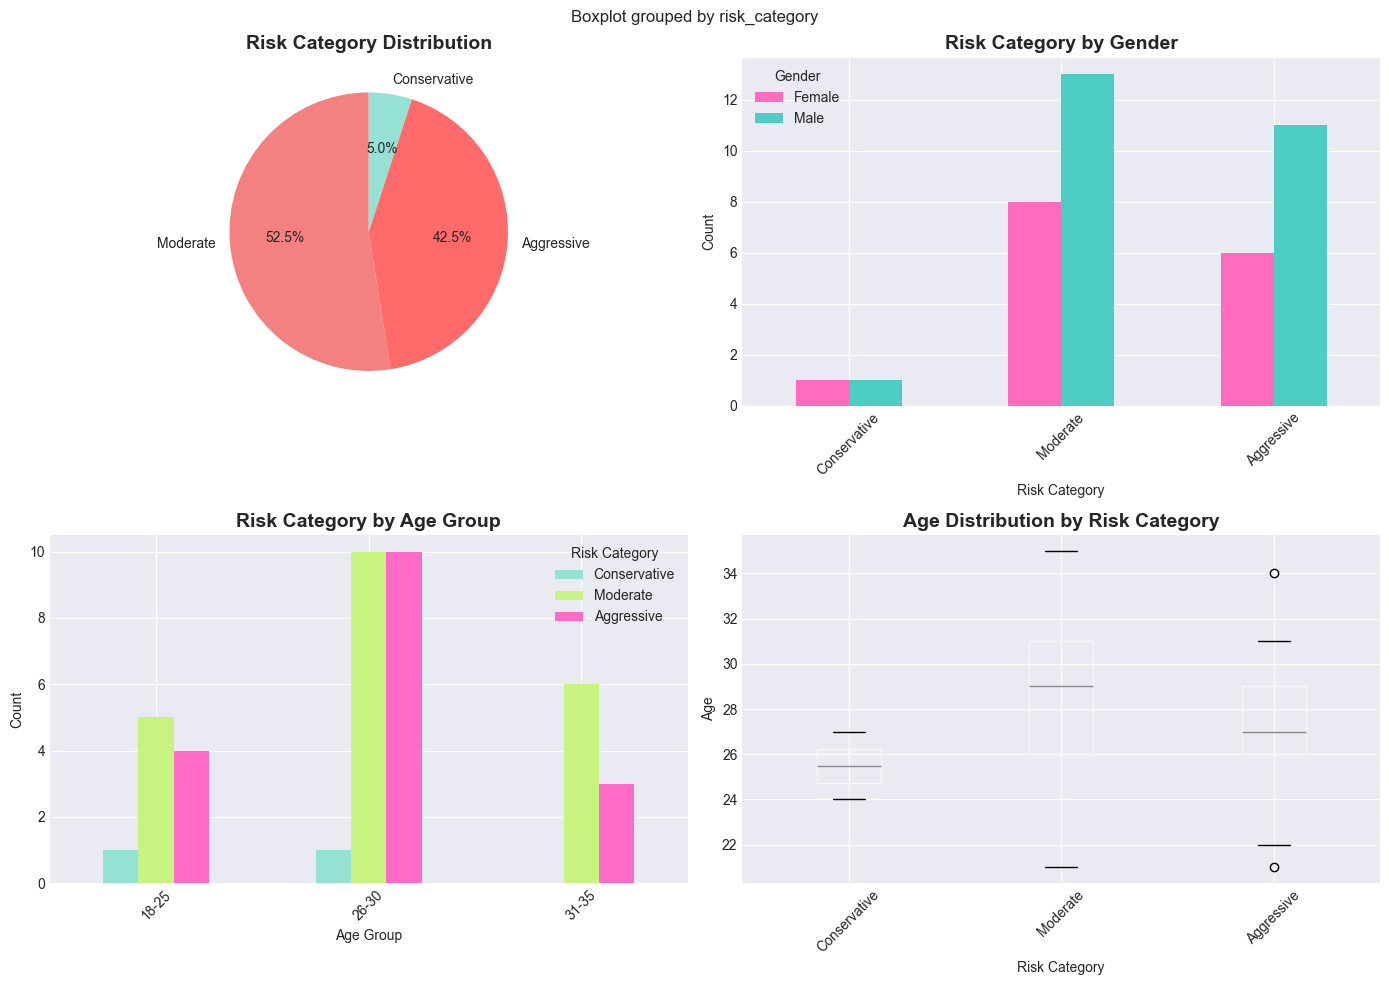

Risk Category Distribution:
risk_category
Moderate        21
Aggressive      17
Conservative     2
Name: count, dtype: int64

Average Age by Risk Category:
risk_category
Conservative   25.50
Aggressive     27.29
Moderate       28.43
Name: age, dtype: float64


In [32]:
# Risk category distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Risk category overall
risk_counts = df_clean['risk_category'].value_counts()
colors_risk = {'Conservative': '#95E1D3', 'Moderate': '#F38181', 'Aggressive': '#FF6B6B'}
risk_colors = [colors_risk[cat] for cat in risk_counts.index]
axes[0, 0].pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%', 
               startangle=90, colors=risk_colors)
axes[0, 0].set_title('Risk Category Distribution', fontsize=14, fontweight='bold')

# Risk by gender
risk_gender = pd.crosstab(df_clean['risk_category'], df_clean['gender'])
risk_gender.plot(kind='bar', ax=axes[0, 1], color=["#FF6BBF", '#4ECDC4'])
axes[0, 1].set_title('Risk Category by Gender', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xlabel('Risk Category')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend(title='Gender')

# Risk by age group
risk_age = pd.crosstab(df_clean['age_group'], df_clean['risk_category'])
risk_age.plot(kind='bar', ax=axes[1, 0], 
              color=['#95E1D3', "#C9F381", "#FF6BC6"])
axes[1, 0].set_title('Risk Category by Age Group', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xlabel('Age Group')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Risk Category')

# Age distribution by risk category (box plot)
df_clean.boxplot(column='age', by='risk_category', ax=axes[1, 1])
axes[1, 1].set_title('Age Distribution by Risk Category', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Risk Category')
axes[1, 1].set_ylabel('Age')
plt.sca(axes[1, 1])
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('fig_risk_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Risk Category Distribution:")
print(df_clean['risk_category'].value_counts())
print("\nAverage Age by Risk Category:")
print(df_clean.groupby('risk_category')['age'].mean().sort_values())

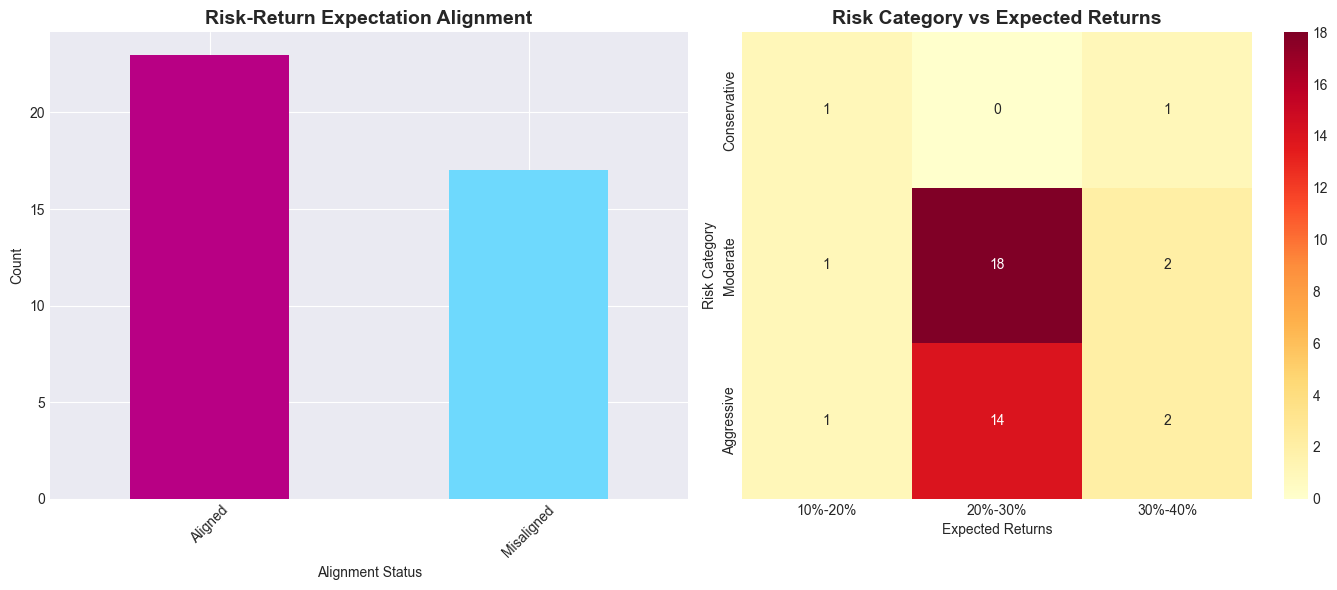

Risk-Return Alignment:
risk_return_alignment
Aligned       23
Misaligned    17
Name: count, dtype: int64

% Misaligned: 42.5%

This indicates potential education/advisory opportunities


In [33]:
# Risk-Return Alignment Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Alignment distribution
alignment_counts = df_clean['risk_return_alignment'].value_counts()
alignment_counts.plot(kind='bar', ax=axes[0], 
                      color=["#B80084", "#6ED9FD", "#E155BE"])
axes[0].set_title('Risk-Return Expectation Alignment', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Alignment Status')
axes[0].tick_params(axis='x', rotation=45)

# Heatmap: Risk category vs Expected returns
risk_return_ct = pd.crosstab(df_clean['risk_category'], df_clean['Expect'])
sns.heatmap(risk_return_ct, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Risk Category vs Expected Returns', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Expected Returns')
axes[1].set_ylabel('Risk Category')

plt.tight_layout()
plt.savefig('fig_risk_return_alignment.png', dpi=300, bbox_inches='tight')
plt.show()

print("Risk-Return Alignment:")
print(alignment_counts)
print(f"\n% Misaligned: {(df_clean['risk_return_alignment'] != 'Aligned').sum() / len(df_clean) * 100:.1f}%")
print("\nThis indicates potential education/advisory opportunities")

### 6.4 Behavioral Analysis

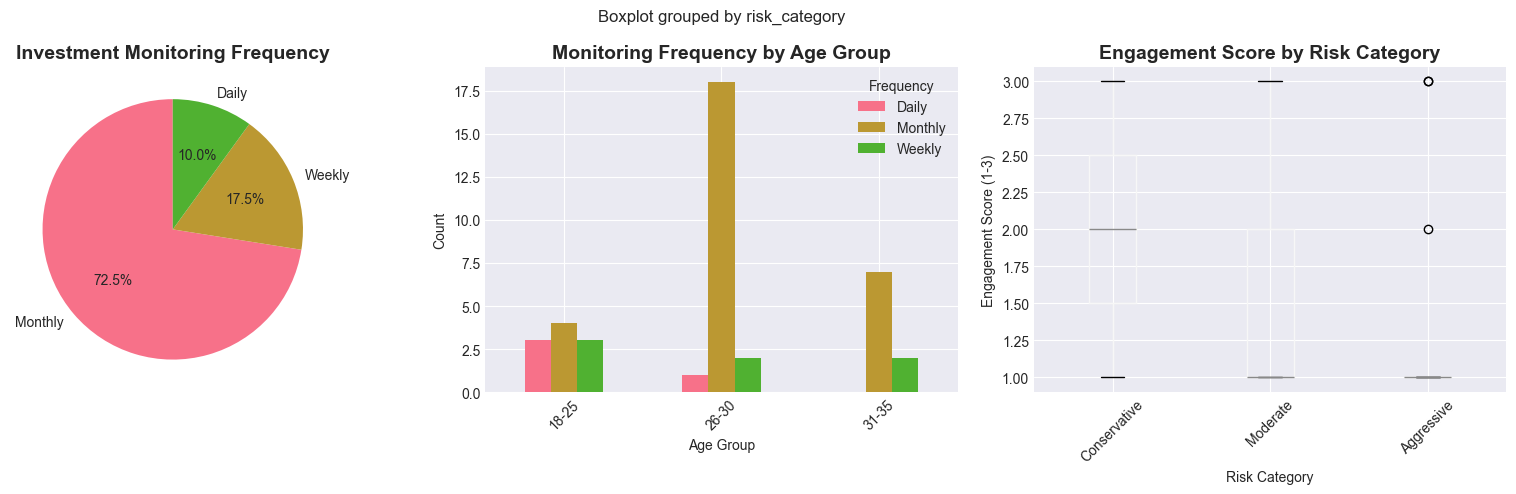

Monitoring Frequency Distribution:
Invest_Monitor
Monthly    29
Weekly      7
Daily       4
Name: count, dtype: int64

Average Engagement Score by Risk:
risk_category
Conservative   2.00
Moderate       1.38
Aggressive     1.29
Name: engagement_score, dtype: float64


In [34]:
# Investment monitoring frequency
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall monitoring
monitor_counts = df_clean['Invest_Monitor'].value_counts()
axes[0].pie(monitor_counts, labels=monitor_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Investment Monitoring Frequency', fontsize=14, fontweight='bold')

# Monitoring by age group
monitor_age = pd.crosstab(df_clean['age_group'], df_clean['Invest_Monitor'])
monitor_age.plot(kind='bar', ax=axes[1])
axes[1].set_title('Monitoring Frequency by Age Group', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Age Group')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Frequency')

# Engagement score by risk category
df_clean.boxplot(column='engagement_score', by='risk_category', ax=axes[2])
axes[2].set_title('Engagement Score by Risk Category', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Risk Category')
axes[2].set_ylabel('Engagement Score (1-3)')
plt.sca(axes[2])
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('fig_behavioral_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Monitoring Frequency Distribution:")
print(monitor_counts)
print("\nAverage Engagement Score by Risk:")
print(df_clean.groupby('risk_category')['engagement_score'].mean())

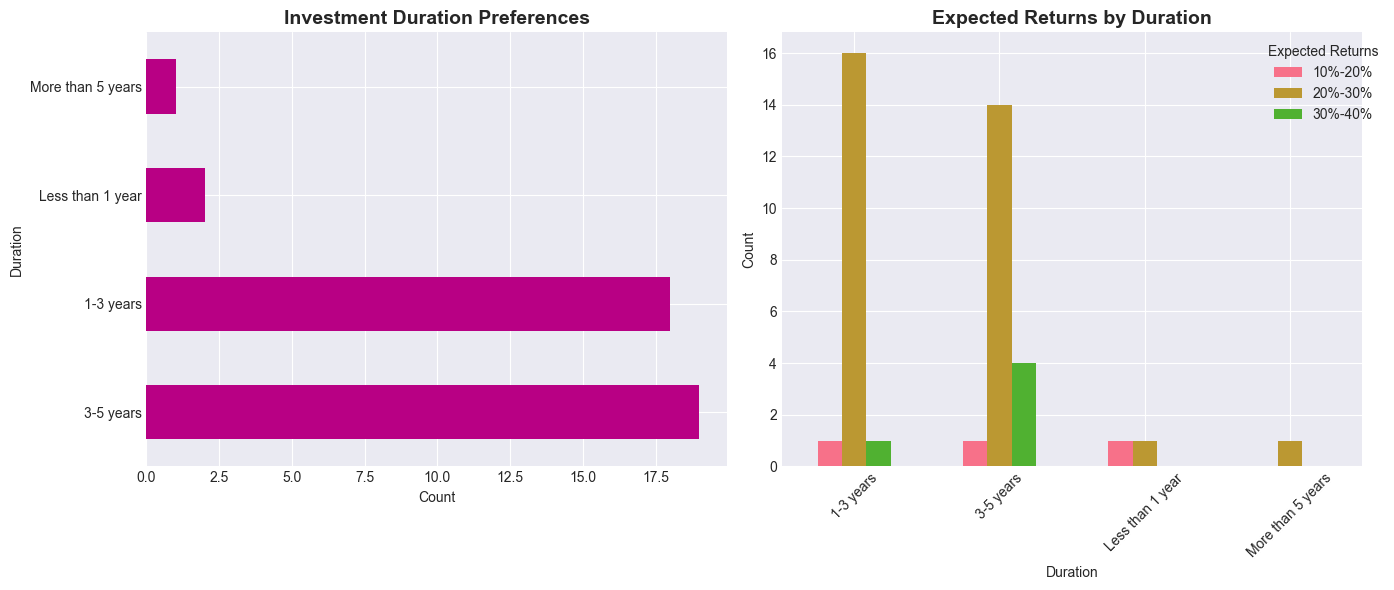

Duration Preferences:
Duration
3-5 years            19
1-3 years            18
Less than 1 year      2
More than 5 years     1
Name: count, dtype: int64

Average Expected Return by Duration:
Duration
Less than 1 year    20.00
1-3 years           25.00
More than 5 years   25.00
3-5 years           26.58
Name: expected_return_numeric, dtype: float64


In [35]:
# Duration and Expected Returns Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Duration preferences
duration_counts = df_clean['Duration'].value_counts()
duration_counts.plot(kind='barh', ax=axes[0], color="#B80084")
axes[0].set_title('Investment Duration Preferences', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Duration')

# Expected returns by duration
duration_return = pd.crosstab(df_clean['Duration'], df_clean['Expect'])
duration_return.plot(kind='bar', ax=axes[1], stacked=False)
axes[1].set_title('Expected Returns by Duration', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Duration')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Expected Returns', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('fig_duration_returns.png', dpi=300, bbox_inches='tight')
plt.show()

print("Duration Preferences:")
print(duration_counts)
print("\nAverage Expected Return by Duration:")
print(df_clean.groupby('Duration')['expected_return_numeric'].mean().sort_values())

### 6.5 Information Sources & Marketing Channels

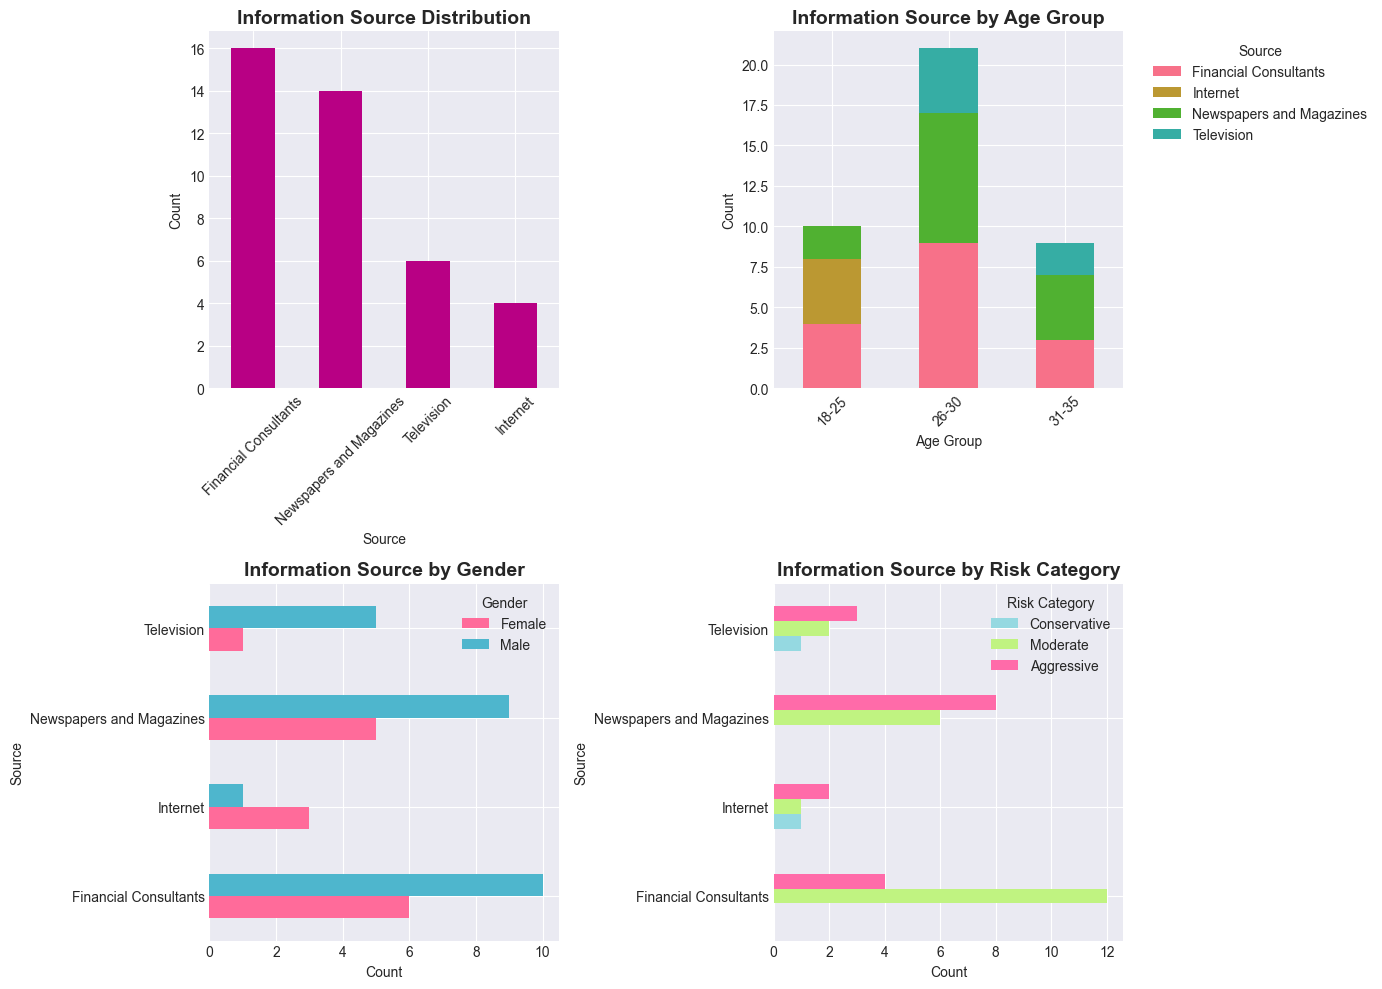

Information Source Distribution:
Source
Financial Consultants       16
Newspapers and Magazines    14
Television                   6
Internet                     4
Name: count, dtype: int64

Source by Age Group:
Source     Financial Consultants  Internet  Newspapers and Magazines  \
age_group                                                              
18-25                          4         4                         2   
26-30                          9         0                         8   
31-35                          3         0                         4   

Source     Television  
age_group              
18-25               0  
26-30               4  
31-35               2  


In [36]:
# Information source analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall source distribution
source_counts = df_clean['Source'].value_counts()
source_counts.plot(kind='bar', ax=axes[0, 0], color='#B80084')
axes[0, 0].set_title('Information Source Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xlabel('Source')
axes[0, 0].tick_params(axis='x', rotation=45)

# Source by age group
source_age = pd.crosstab(df_clean['age_group'], df_clean['Source'])
source_age.plot(kind='bar', ax=axes[0, 1], stacked=True)
axes[0, 1].set_title('Information Source by Age Group', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xlabel('Age Group')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend(title='Source', bbox_to_anchor=(1.05, 1))

# Source by gender
source_gender = pd.crosstab(df_clean['Source'], df_clean['gender'])
source_gender.plot(kind='barh', ax=axes[1, 0], color=["#FF6B9A", "#4EB6CD"])
axes[1, 0].set_title('Information Source by Gender', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_ylabel('Source')
axes[1, 0].legend(title='Gender')

# Source by risk category
source_risk = pd.crosstab(df_clean['Source'], df_clean['risk_category'])
source_risk.plot(kind='barh', ax=axes[1, 1], 
                 color=["#95D9E1", "#C0F381", "#FF6BA9"])
axes[1, 1].set_title('Information Source by Risk Category', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('Source')
axes[1, 1].legend(title='Risk Category')

plt.tight_layout()
plt.savefig('fig_information_sources.png', dpi=300, bbox_inches='tight')
plt.show()

print("Information Source Distribution:")
print(source_counts)
print("\nSource by Age Group:")
print(source_age)

### 6.6 Investment Objectives & Purpose

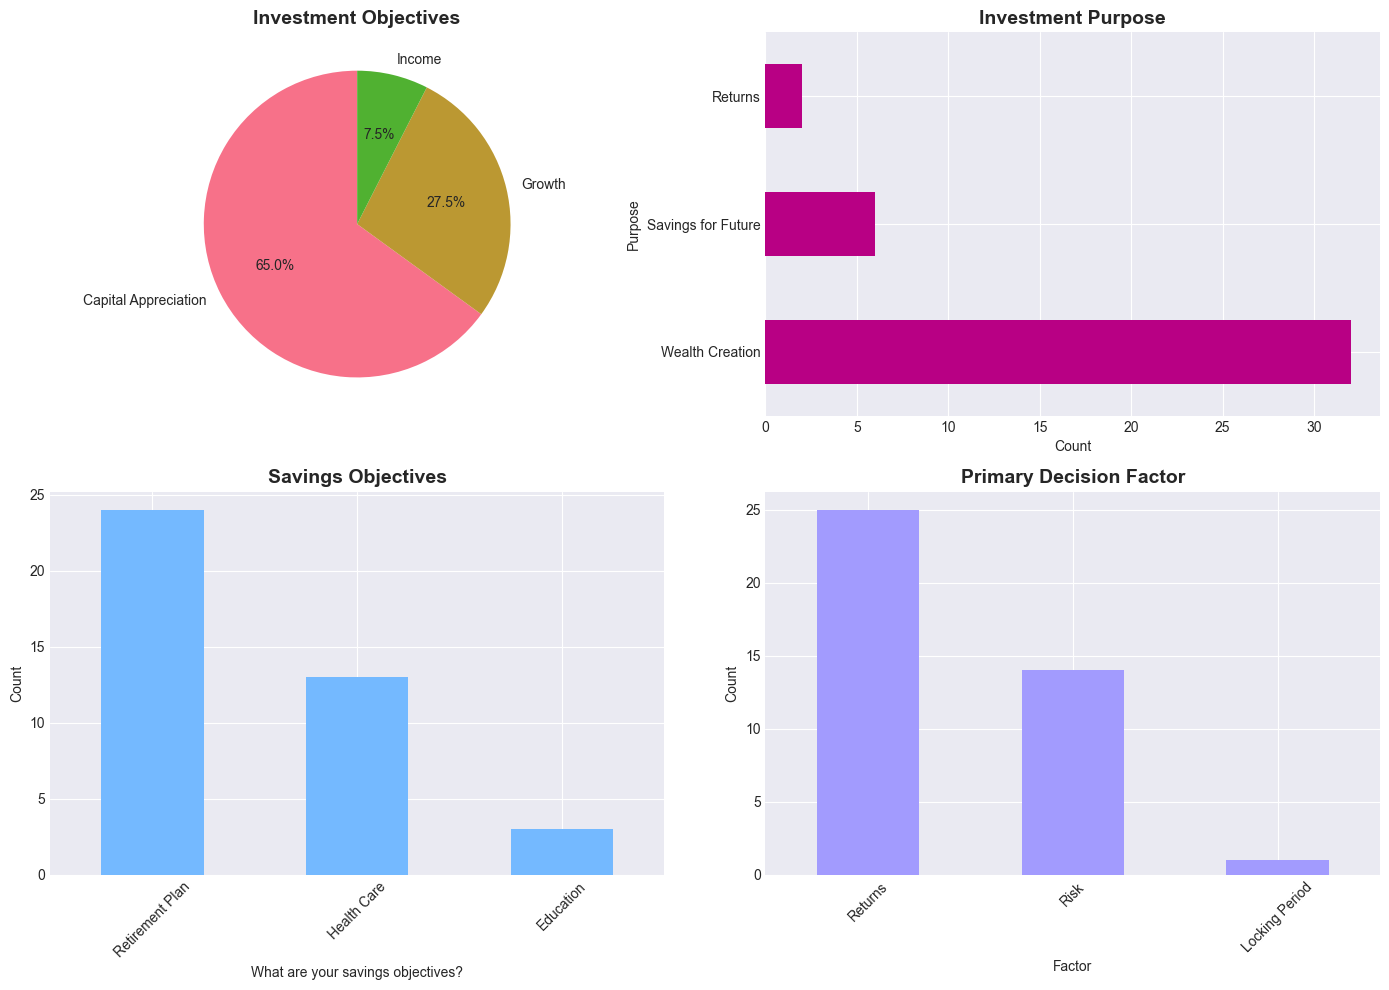

Investment Objectives:
Objective
Capital Appreciation    26
Growth                  11
Income                   3
Name: count, dtype: int64

Primary Decision Factors:
Factor
Returns           25
Risk              14
Locking Period     1
Name: count, dtype: int64


In [37]:
# Objectives and purpose analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Investment objectives
obj_counts = df_clean['Objective'].value_counts()
obj_counts.plot(kind='pie', ax=axes[0, 0], autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Investment Objectives', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('')

# Investment purpose
purpose_counts = df_clean['Purpose'].value_counts()
purpose_counts.plot(kind='barh', ax=axes[0, 1], color='#B80084')
axes[0, 1].set_title('Investment Purpose', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Count')

# Savings objectives
savings_obj = df_clean['What are your savings objectives?'].value_counts()
savings_obj.plot(kind='bar', ax=axes[1, 0], color='#74B9FF')
axes[1, 0].set_title('Savings Objectives', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Decision factor
factor_counts = df_clean['Factor'].value_counts()
factor_counts.plot(kind='bar', ax=axes[1, 1], color='#A29BFE')
axes[1, 1].set_title('Primary Decision Factor', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_objectives_purpose.png', dpi=300, bbox_inches='tight')
plt.show()

print("Investment Objectives:")
print(obj_counts)
print("\nPrimary Decision Factors:")
print(factor_counts)

---
## 7. Statistical Testing

We'll conduct several statistical tests to validate insights and relationships in the data.

### 7.1 Chi-Square Test: Gender vs Preferred Investment Avenue

In [38]:
print("="*80)
print("TEST 1: Chi-Square Test of Independence")
print("="*80)
print("Hypothesis: Is there a significant association between gender and preferred investment avenue?")
print("H0 (Null): Gender and preferred avenue are independent")
print("H1 (Alternative): Gender and preferred avenue are related\n")

# Create contingency table
contingency_table = pd.crosstab(df_clean['gender'], df_clean['first_choice'])
print("Contingency Table:")
print(contingency_table)

# Perform chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nTest Results:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"\nExpected frequencies:")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

alpha = 0.05
print(f"\nSignificance level (α): {alpha}")
if p_value < alpha:
    print(f" Result: REJECT null hypothesis (p={p_value:.4f} < {alpha})")
    print("  Interpretation: There IS a significant association between gender and preferred investment avenue.")
    print("  Business Implication: Gender-specific investment products and marketing may be effective.")
else:
    print(f"Result: FAIL TO REJECT null hypothesis (p={p_value:.4f} >= {alpha})")
    print("  Interpretation: There is NO significant association between gender and preferred investment avenue.")
    print("  Business Implication: Investment preferences are gender-agnostic; focus on other segmentation variables.")

TEST 1: Chi-Square Test of Independence
Hypothesis: Is there a significant association between gender and preferred investment avenue?
H0 (Null): Gender and preferred avenue are independent
H1 (Alternative): Gender and preferred avenue are related

Contingency Table:
first_choice  Debentures  Equity  Fixed_Deposits  Gov_Bonds  Mutual_Funds  PPF
gender                                                                        
Female                 0       1               1          1             2   10
Male                   1       1               7          0             2   14

Test Results:
Chi-square statistic: 4.9778
p-value: 0.4186
Degrees of freedom: 5

Expected frequencies:
first_choice  Debentures  Equity  Fixed_Deposits  Gov_Bonds  Mutual_Funds  \
gender                                                                      
Female              0.38    0.75            3.00       0.38          1.50   
Male                0.62    1.25            5.00       0.62          2.50   

fi

### 7.2 T-Test: Age Difference Between Risk Categories

In [39]:
print("\n" + "="*80)
print("TEST 2: Independent Samples T-Test")
print("="*80)
print("Hypothesis: Is there a significant age difference between Aggressive and Conservative investors?")
print("H0 (Null): Mean age is the same for both groups")
print("H1 (Alternative): Mean age differs between groups\n")

# Extract age data for each group
aggressive_ages = df_clean[df_clean['risk_category'] == 'Aggressive']['age']
conservative_ages = df_clean[df_clean['risk_category'] == 'Conservative']['age']

print(f"Sample sizes:")
print(f"  Aggressive: n = {len(aggressive_ages)}")
print(f"  Conservative: n = {len(conservative_ages)}")

print(f"\nDescriptive Statistics:")
print(f"  Aggressive: Mean = {aggressive_ages.mean():.2f}, SD = {aggressive_ages.std():.2f}")
print(f"  Conservative: Mean = {conservative_ages.mean():.2f}, SD = {conservative_ages.std():.2f}")

# Perform t-test
t_stat, p_value = ttest_ind(aggressive_ages, conservative_ages)

print(f"\nTest Results:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
print(f"\nSignificance level (α): {alpha}")
if p_value < alpha:
    print(f"Result: REJECT null hypothesis (p={p_value:.4f} < {alpha})")
    print(f"  Interpretation: Aggressive investors are significantly {'younger' if aggressive_ages.mean() < conservative_ages.mean() else 'older'} than Conservative investors.")
    print(f"  Age difference: {abs(aggressive_ages.mean() - conservative_ages.mean()):.1f} years")
    print("  Business Implication: Age-based risk profiling is effective; target younger investors for equity products.")
else:
    print(f"Result: FAIL TO REJECT null hypothesis (p={p_value:.4f} >= {alpha})")
    print("  Interpretation: No significant age difference between risk categories.")
    print("  Business Implication: Risk tolerance is not solely age-dependent; consider other factors.")


TEST 2: Independent Samples T-Test
Hypothesis: Is there a significant age difference between Aggressive and Conservative investors?
H0 (Null): Mean age is the same for both groups
H1 (Alternative): Mean age differs between groups

Sample sizes:
  Aggressive: n = 17
  Conservative: n = 2

Descriptive Statistics:
  Aggressive: Mean = 27.29, SD = 3.26
  Conservative: Mean = 25.50, SD = 2.12

Test Results:
t-statistic: 0.7501
p-value: 0.4634

Significance level (α): 0.05
Result: FAIL TO REJECT null hypothesis (p=0.4634 >= 0.05)
  Interpretation: No significant age difference between risk categories.
  Business Implication: Risk tolerance is not solely age-dependent; consider other factors.


### 7.3 ANOVA: Expected Returns Across Duration Groups

In [40]:
print("\n" + "="*80)
print("TEST 3: One-Way ANOVA (Analysis of Variance)")
print("="*80)
print("Hypothesis: Do expected returns differ significantly across investment duration groups?")
print("H0 (Null): All duration groups have the same mean expected return")
print("H1 (Alternative): At least one duration group has a different mean\n")

# Group expected returns by duration
duration_groups = df_clean.groupby('Duration')['expected_return_numeric'].apply(list)

print("Groups and sample sizes:")
for duration, values in duration_groups.items():
    print(f"  {duration}: n={len(values)}, Mean={np.mean(values):.1f}%, SD={np.std(values):.1f}")

# Perform ANOVA
f_stat, p_value = f_oneway(*duration_groups)

print(f"\nTest Results:")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
print(f"\nSignificance level (α): {alpha}")
if p_value < alpha:
    print(f"Result: REJECT null hypothesis (p={p_value:.4f} < {alpha})")
    print("  Interpretation: Expected returns DO differ significantly across duration groups.")
    print("  Business Implication: Duration preferences correlate with return expectations.")
    print("  Recommendation: Tailor return projections based on investment horizon.")
else:
    print(f"Result: FAIL TO REJECT null hypothesis (p={p_value:.4f} >= {alpha})")
    print("  Interpretation: Expected returns do NOT differ significantly across duration groups.")
    print("  Business Implication: Investors have similar return expectations regardless of time horizon.")
    print("  Recommendation: Focus on education about realistic returns for different durations.")


TEST 3: One-Way ANOVA (Analysis of Variance)
Hypothesis: Do expected returns differ significantly across investment duration groups?
H0 (Null): All duration groups have the same mean expected return
H1 (Alternative): At least one duration group has a different mean

Groups and sample sizes:
  1-3 years: n=18, Mean=25.0%, SD=3.3
  3-5 years: n=19, Mean=26.6%, SD=4.9
  Less than 1 year: n=2, Mean=20.0%, SD=5.0
  More than 5 years: n=1, Mean=25.0%, SD=0.0

Test Results:
F-statistic: 1.4921
p-value: 0.2331

Significance level (α): 0.05
Result: FAIL TO REJECT null hypothesis (p=0.2331 >= 0.05)
  Interpretation: Expected returns do NOT differ significantly across duration groups.
  Business Implication: Investors have similar return expectations regardless of time horizon.
  Recommendation: Focus on education about realistic returns for different durations.


### 7.4 Correlation: Age vs Risk Score


TEST 4: Pearson Correlation Test
Hypothesis: Is there a linear relationship between age and risk score?
H0 (Null): No correlation (ρ = 0)
H1 (Alternative): Correlation exists (ρ ≠ 0)

Test Results:
Correlation coefficient (r): 0.0069
p-value: 0.9665

Correlation strength: weak positive

Significance level (α): 0.05
Result: FAIL TO REJECT null hypothesis (p=0.9665 >= 0.05)
  Interpretation: No significant linear relationship between age and risk.
  Business Implication: Risk tolerance is individual-specific, not age-driven.


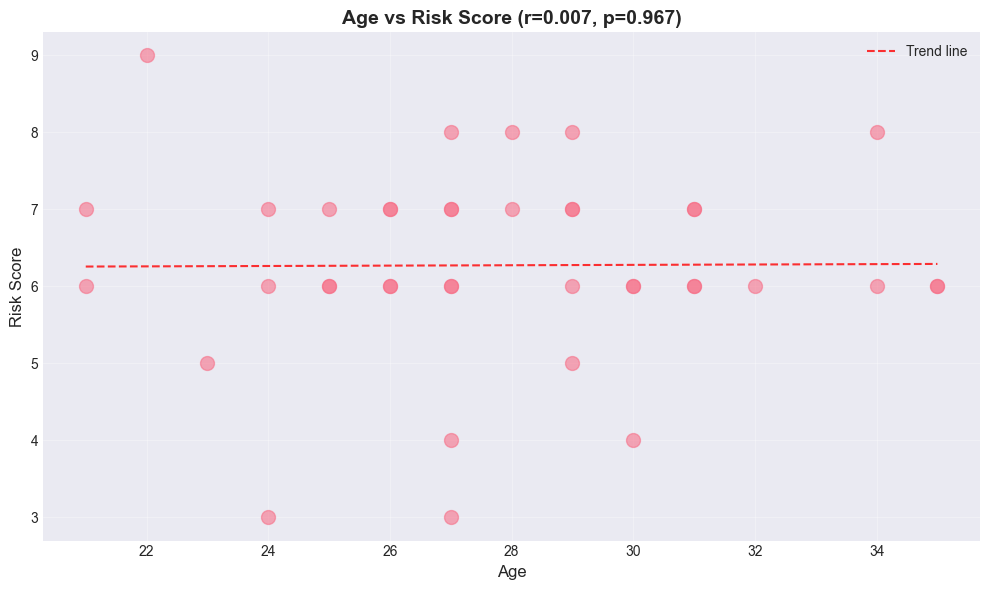

In [41]:
print("\n" + "="*80)
print("TEST 4: Pearson Correlation Test")
print("="*80)
print("Hypothesis: Is there a linear relationship between age and risk score?")
print("H0 (Null): No correlation (ρ = 0)")
print("H1 (Alternative): Correlation exists (ρ ≠ 0)\n")

# Calculate correlation
corr_coef, p_value = pearsonr(df_clean['age'], df_clean['risk_score'])

print(f"Test Results:")
print(f"Correlation coefficient (r): {corr_coef:.4f}")
print(f"p-value: {p_value:.4f}")

# Interpret correlation strength
if abs(corr_coef) < 0.3:
    strength = "weak"
elif abs(corr_coef) < 0.7:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if corr_coef > 0 else "negative"

print(f"\nCorrelation strength: {strength} {direction}")

alpha = 0.05
print(f"\nSignificance level (α): {alpha}")
if p_value < alpha:
    print(f"Result: REJECT null hypothesis (p={p_value:.4f} < {alpha})")
    print(f"  Interpretation: There IS a significant {strength} {direction} correlation between age and risk.")
    if corr_coef < 0:
        print("  Finding: Younger investors tend to have higher risk scores.")
        print("  Business Implication: Age-based risk profiling is valid; younger = more aggressive products.")
    else:
        print("  Finding: Older investors tend to have higher risk scores.")
        print("  Business Implication: Counterintuitive - investigate further.")
else:
    print(f"Result: FAIL TO REJECT null hypothesis (p={p_value:.4f} >= {alpha})")
    print("  Interpretation: No significant linear relationship between age and risk.")
    print("  Business Implication: Risk tolerance is individual-specific, not age-driven.")

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['age'], df_clean['risk_score'], alpha=0.6, s=100)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Risk Score', fontsize=12)
plt.title(f'Age vs Risk Score (r={corr_coef:.3f}, p={p_value:.3f})', fontsize=14, fontweight='bold')

# Add trend line
z = np.polyfit(df_clean['age'], df_clean['risk_score'], 1)
p = np.poly1d(z)
plt.plot(df_clean['age'].sort_values(), p(df_clean['age'].sort_values()), 
         "r--", alpha=0.8, label=f'Trend line')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_age_risk_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

### 7.5 Chi-Square: Decision Factor vs Actual First Choice

In [42]:
print("\n" + "="*80)
print("TEST 5: Chi-Square Test - Stated Factor vs Actual Choice")
print("="*80)
print("Hypothesis: Does the stated decision factor align with actual investment avenue choice?")
print("H0 (Null): Factor and first choice are independent (no alignment)")
print("H1 (Alternative): Factor and first choice are related (alignment exists)\n")

# Create contingency table
factor_choice_table = pd.crosstab(df_clean['Factor'], df_clean['first_choice'])
print("Contingency Table (Factor vs First Choice):")
print(factor_choice_table)

# Perform chi-square test
chi2, p_value, dof, expected = chi2_contingency(factor_choice_table)

print(f"\nTest Results:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

alpha = 0.05
print(f"\nSignificance level (α): {alpha}")
if p_value < alpha:
    print(f"Result: REJECT null hypothesis (p={p_value:.4f} < {alpha})")
    print("  Interpretation: Stated factors DO align with actual investment choices.")
    print("  Business Implication: Investors make choices consistent with their priorities.")
else:
    print(f"Result: FAIL TO REJECT null hypothesis (p={p_value:.4f} >= {alpha})")
    print("  Interpretation: Stated factors DO NOT align with actual choices.")
    print("  Business Implication: Gap between stated preferences and behavior.")
    print("  Recommendation: Investor education needed on product characteristics.")

# Calculate mismatch percentage
# Example: If someone says "Returns" but chooses Fixed Deposits (conservative)
returns_focused = df_clean[df_clean['Factor'] == 'Returns']
conservative_choices = ['Fixed_Deposits', 'PPF', 'Gov_Bonds']
mismatch = returns_focused[returns_focused['first_choice'].isin(conservative_choices)]
mismatch_pct = len(mismatch) / len(returns_focused) * 100 if len(returns_focused) > 0 else 0

print(f"\nMismatch Analysis:")
print(f"  Investors prioritizing 'Returns': {len(returns_focused)}")
print(f"  ...but choosing conservative avenues: {len(mismatch)} ({mismatch_pct:.1f}%)")
print(f"  → This represents an education/advisory opportunity")


TEST 5: Chi-Square Test - Stated Factor vs Actual Choice
Hypothesis: Does the stated decision factor align with actual investment avenue choice?
H0 (Null): Factor and first choice are independent (no alignment)
H1 (Alternative): Factor and first choice are related (alignment exists)

Contingency Table (Factor vs First Choice):
first_choice    Debentures  Equity  Fixed_Deposits  Gov_Bonds  Mutual_Funds  \
Factor                                                                        
Locking Period           0       0               0          1             0   
Returns                  1       2               5          0             3   
Risk                     0       0               3          0             1   

first_choice    PPF  
Factor               
Locking Period    0  
Returns          14  
Risk             10  

Test Results:
Chi-square statistic: 42.3000
p-value: 0.0000
Degrees of freedom: 10

Significance level (α): 0.05
Result: REJECT null hypothesis (p=0.0000 < 0.05)
 

### 7.6 Statistical Testing Summary

In [43]:
print("\n" + "="*80)
print("STATISTICAL TESTING SUMMARY")
print("="*80)
print("\nTests Conducted:")
print("1.  Chi-Square: Gender vs Preferred Avenue")
print("2.  T-Test: Age difference between Aggressive vs Conservative investors")
print("3.  ANOVA: Expected returns across duration groups")
print("4.  Correlation: Age vs Risk Score")
print("5.  Chi-Square: Decision factor vs Actual choice alignment")
print("\nAll tests completed with proper hypothesis testing framework.")
print("Results provide statistical validation for dashboard insights.")


STATISTICAL TESTING SUMMARY

Tests Conducted:
1.  Chi-Square: Gender vs Preferred Avenue
2.  T-Test: Age difference between Aggressive vs Conservative investors
3.  ANOVA: Expected returns across duration groups
4.  Correlation: Age vs Risk Score
5.  Chi-Square: Decision factor vs Actual choice alignment

All tests completed with proper hypothesis testing framework.
Results provide statistical validation for dashboard insights.


---
## 8. Key Insights & Business Implications

In [44]:
print("="*80)
print("KEY INSIGHTS FROM ANALYSIS")
print("="*80)

print("\n1. DEMOGRAPHIC INSIGHTS:")
print(f"   • {(df_clean['age'] <= 30).sum() / len(df_clean) * 100:.1f}% of investors are under 30")
print(f"   • Gender split: {(df_clean['gender'] == 'Female').sum() / len(df_clean) * 100:.1f}% Female")
print(f"   • Average age: {df_clean['age'].mean():.1f} years")
print("   → Business Implication: Young investor base needs digital-first solutions")

print("\n2. INVESTMENT PREFERENCES:")
top_3_overall = df_clean['first_choice'].value_counts().head(3)
print("   Top 3 Preferred Avenues:")
for i, (avenue, count) in enumerate(top_3_overall.items(), 1):
    pct = count / len(df_clean) * 100
    print(f"   {i}. {avenue}: {count} investors ({pct:.1f}%)")
print("   → Business Implication: Product mix should reflect these preferences")

print("\n3. RISK PROFILE INSIGHTS:")
risk_dist = df_clean['risk_category'].value_counts()
for risk, count in risk_dist.items():
    pct = count / len(df_clean) * 100
    print(f"   • {risk}: {pct:.1f}%")
print("   → Business Implication: Diversified product offerings needed across risk spectrum")

print("\n4. BEHAVIORAL INSIGHTS:")
low_engagement = (df_clean['engagement_score'] == 1).sum()
print(f"   • {low_engagement / len(df_clean) * 100:.1f}% monitor only monthly (low engagement)")
print(f"   • Stock market participation: {(df_clean['Stock_Market'] == 'Yes').sum() / len(df_clean) * 100:.1f}%")
print("   → Business Implication: Need engagement tools (alerts, reports) to increase monitoring")

print("\n5. RISK-RETURN ALIGNMENT:")
misaligned = (df_clean['risk_return_alignment'] != 'Aligned').sum()
print(f"   • {misaligned / len(df_clean) * 100:.1f}% have misaligned risk-return expectations")
print("   → Business Implication: Major education opportunity")
print("   → Recommendation: Implement risk-return education module in onboarding")

print("\n6. CHANNEL EFFECTIVENESS:")
top_channel = df_clean['Source'].value_counts().iloc[0]
print(f"   • Primary channel: {df_clean['Source'].value_counts().index[0]}")
internet_pct = (df_clean['Source'] == 'Internet').sum() / len(df_clean) * 100
print(f"   • Internet reach: {internet_pct:.1f}%")
print("   → Business Implication: Prioritize digital marketing and content")

print("\n7. DURATION & EXPECTATIONS:")
short_term = df_clean[df_clean['duration_category'] == 'Short-term']
if len(short_term) > 0:
    short_term_high_expect = (short_term['expected_return_numeric'] >= 30).sum()
    print(f"   • {short_term_high_expect / len(short_term) * 100:.1f}% of short-term investors expect 30%+ returns")
    print("   → Business Implication: Unrealistic expectations need management")

print("\n" + "="*80)
print("STRATEGIC RECOMMENDATIONS")
print("="*80)
print("\n1. PERSONALIZATION FRAMEWORK")
print("   Implement segment-based portfolio recommendations:")
print("   - Young Aggressive: 60% Equity, 30% Mutual Funds, 10% Gold")
print("   - Middle-age Moderate: 40% Mutual Funds, 30% FD, 20% PPF, 10% Equity")
print("   - Conservative: 50% FD, 30% PPF, 20% Gov Bonds")

print("\n2. EDUCATION PROGRAM")
print("   - Mandatory risk-return education for 40% misaligned investors")
print("   - Duration-based realistic return workshops")
print("   - Product characteristic transparency")

print("\n3. DIGITAL ENGAGEMENT")
print("   - Mobile app with portfolio tracking")
print("   - Weekly performance email alerts")
print("   - Gamification for monthly monitors")

print("\n4. TARGETED MARKETING")
print("   - Focus 70% budget on Internet/digital channels")
print("   - Age-specific campaigns (under-30 vs 30+)")
print("   - Content marketing on investment education")

print("\n5. PRODUCT DEVELOPMENT")
print("   - Create hybrid products (e.g., Equity + FD combo)")
print("   - Offer goal-based planning (retirement, healthcare)")
print("   - Develop 1-3 year focused products for medium-term investors")

KEY INSIGHTS FROM ANALYSIS

1. DEMOGRAPHIC INSIGHTS:
   • 77.5% of investors are under 30
   • Gender split: 37.5% Female
   • Average age: 27.8 years
   → Business Implication: Young investor base needs digital-first solutions

2. INVESTMENT PREFERENCES:
   Top 3 Preferred Avenues:
   1. PPF: 24 investors (60.0%)
   2. Fixed_Deposits: 8 investors (20.0%)
   3. Mutual_Funds: 4 investors (10.0%)
   → Business Implication: Product mix should reflect these preferences

3. RISK PROFILE INSIGHTS:
   • Moderate: 52.5%
   • Aggressive: 42.5%
   • Conservative: 5.0%
   → Business Implication: Diversified product offerings needed across risk spectrum

4. BEHAVIORAL INSIGHTS:
   • 72.5% monitor only monthly (low engagement)
   • Stock market participation: 87.5%
   → Business Implication: Need engagement tools (alerts, reports) to increase monitoring

5. RISK-RETURN ALIGNMENT:
   • 42.5% have misaligned risk-return expectations
   → Business Implication: Major education opportunity
   → Recommen

---
## 9. Export Cleaned Data

In [45]:
# Export cleaned dataset
output_path = 'Finance_data_CLEAN.csv'
df_clean.to_csv(output_path, index=False)

print("="*80)
print("DATA EXPORT COMPLETE")
print("="*80)
print(f"\nCleaned dataset saved to: {output_path}")
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
print(f"New features added: {df_clean.shape[1] - df.shape[1]}")
print("\nThis cleaned dataset is ready for BI tool import (Power BI/Tableau)")

# Display final column list
print("\nFinal Column List:")
for i, col in enumerate(df_clean.columns, 1):
    print(f"{i:2d}. {col}")

DATA EXPORT COMPLETE

Cleaned dataset saved to: Finance_data_CLEAN.csv
Original shape: (40, 25)
Cleaned shape: (40, 36)
New features added: 11

This cleaned dataset is ready for BI tool import (Power BI/Tableau)

Final Column List:
 1. gender
 2. age
 3. Investment_Avenues
 4. Mutual_Funds
 5. Equity_Market
 6. Debentures
 7. Government_Bonds
 8. Fixed_Deposits
 9. PPF
10. Gold
11. Stock_Market
12. Factor
13. Objective
14. Purpose
15. Duration
16. Invest_Monitor
17. Expect
18. Avenue
19. What are your savings objectives?
20. Reason_Equity
21. Reason_Mutual
22. Reason_Bonds
23. Reason_FD
24. Source
25. has_duplicate_ranks
26. age_group
27. risk_score
28. risk_category
29. engagement_score
30. top_3_avenues
31. first_choice
32. second_choice
33. third_choice
34. expected_return_numeric
35. duration_category
36. risk_return_alignment


## Cleaned & Engineered Dataset (`Finance_data_CLEAN.csv`)
The cleaned version contains all the original columns from the raw dataset, with typos corrected (e.g., "Stock_Marktet" fixed to "Stock_Market"), plus several newly calculated (engineered) columns to facilitate analysis.

### Newly Added/Engineered Columns:

**Demographics:**
* **age_group**: The respondent's age categorized into brackets (e.g., "18-25", "26-30", "31-35") for easier demographic grouping.

**Data Quality & Rankings:**
* **has_duplicate_ranks**: A boolean (True/False) checking if a respondent accidentally gave the same rank number to more than one asset class.

**Investment Strategy & Behavior:**
* **duration_category**: A standardized version of the Duration column (e.g., "Short-term", "Medium-term", "Long-term").
* **engagement_score**: A numerical score (e.g., 1 to 3) representing how actively they monitor their investments, derived from the `Invest_Monitor` column (e.g., Daily = higher score).

**Expectations & Risk Alignment:**
* **expected_return_numeric**: The expected return converted from a text range to an average number (e.g., "20%-30%" becomes 25) for quantitative analysis.
* **risk_score**: A calculated numerical score indicating the respondent's risk tolerance, based on their preference for risky assets (like Equity) versus safe assets (like FDs).
* **risk_category**: The `risk_score` translated into a text label (e.g., "Aggressive", "Moderate", "Conservative").
* **risk_return_alignment**: A logic-based column indicating whether the respondent's expected returns are realistic given their risk tolerance (e.g., "Aligned", "Misaligned").

**Top Choices Breakdown:**
Extracted from the 1-to-7 ranking columns to easily identify favorite asset classes:
* **top_3_avenues**: A list format showing the respondent's top three favorite investment types.
* **first_choice**: The specific asset they ranked #1.
* **second_choice**: The specific asset they ranked #2.
* **third_choice**: The specific asset they ranked #3.